In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.impute import KNNImputer

In [2]:
dataset = os.path.join('datasets', 'diabetes.csv')
df = pd.read_csv(dataset)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.rename({'Pregnancies': 'preg', 'Glucose': 'plas', 'BloodPressure': 'pres', 'SkinThickness': 'skin', 'Insulin': 'test', 'BMI': 'mass',
            'DiabetesPedigreeFunction': 'pedi', 'Age': 'age', 'Outcome': 'class'}, axis=1,inplace=True)
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.isnull().sum()

preg     0
plas     0
pres     0
skin     0
test     0
mass     0
pedi     0
age      0
class    0
dtype: int64

In [5]:
df.isna().sum()

preg     0
plas     0
pres     0
skin     0
test     0
mass     0
pedi     0
age      0
class    0
dtype: int64

<Axes: >

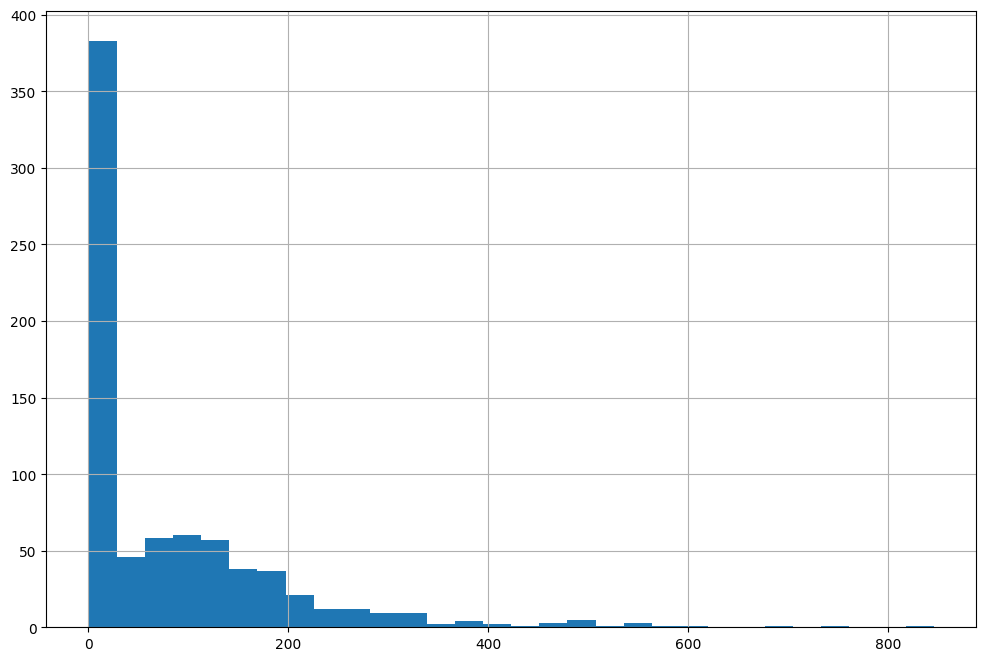

In [6]:
df['test'].hist(bins=30, figsize=(12, 8))

In [7]:
df.shape

(768, 9)

In [8]:
print(df[df['test'] == 0]['test'].value_counts())

test
0    374
Name: count, dtype: int64


In [9]:
df[df['skin'] == 0]['skin'].value_counts()

skin
0    227
Name: count, dtype: int64

In [10]:
skines = df[df['skin'] == 0]
skines

,preg,plas,pres,skin,test,mass,pedi,age,class
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
9,8,125,96,0,0,0.0,0.232,54,1
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
757,0,123,72,0,0,36.3,0.258,52,1
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
762,9,89,62,0,0,22.5,0.142,33,0


In [11]:
skin_mean = df[df['skin'] != 0]['skin'].mean().round(2)
skin_mean

np.float64(29.15)

In [12]:
df.replace({'skin': 0}, skin_mean, inplace=True)
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35.00,0,33.6,0.627,50,1
1,1,85,66,29.00,0,26.6,0.351,31,0
2,8,183,64,29.15,0,23.3,0.672,32,1
3,1,89,66,23.00,94,28.1,0.167,21,0
4,0,137,40,35.00,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00,180,32.9,0.171,63,0
764,2,122,70,27.00,0,36.8,0.340,27,0
765,5,121,72,23.00,112,26.2,0.245,30,0
766,1,126,60,29.15,0,30.1,0.349,47,1


<Axes: >

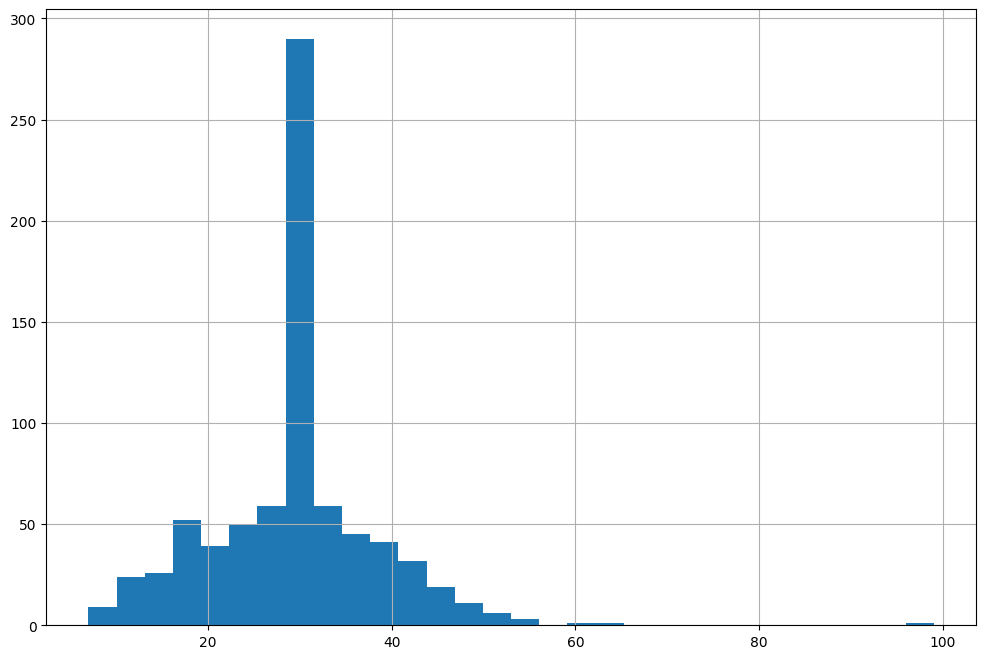

In [13]:
df['skin'].hist(bins=30, figsize=(12, 8))

In [14]:
df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,29.152409,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,8.790942,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,25.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.150000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
test_mean = df[df['test'] != 0]['test'].mean().round(2)
test_mean

np.float64(155.55)

In [16]:
df.replace({'test': 0}, test_mean, inplace=True)
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35.00,155.55,33.6,0.627,50,1
1,1,85,66,29.00,155.55,26.6,0.351,31,0
2,8,183,64,29.15,155.55,23.3,0.672,32,1
3,1,89,66,23.00,94.00,28.1,0.167,21,0
4,0,137,40,35.00,168.00,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00,180.00,32.9,0.171,63,0
764,2,122,70,27.00,155.55,36.8,0.340,27,0
765,5,121,72,23.00,112.00,26.2,0.245,30,0
766,1,126,60,29.15,155.55,30.1,0.349,47,1


In [17]:
dataset = os.path.join('datasets', 'diabetes.csv')
df = pd.read_csv(dataset)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [18]:
df.rename({'Pregnancies': 'preg', 'Glucose': 'plas', 'BloodPressure': 'pres', 'SkinThickness': 'skin', 'Insulin': 'test', 'BMI': 'mass',
            'DiabetesPedigreeFunction': 'pedi', 'Age': 'age', 'Outcome': 'class'}, axis=1,inplace=True)
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [19]:
df.replace({'skin': 0, 'test': 0}, np.nan, inplace=True)
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35.0,NaN,33.6,0.627,50,1
1,1,85,66,29.0,NaN,26.6,0.351,31,0
2,8,183,64,NaN,NaN,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,NaN,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,NaN,NaN,30.1,0.349,47,1


In [20]:
imputer = KNNImputer(n_neighbors=3)
data_impute = imputer.fit_transform(df.iloc[:, :-1])
data_impute

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]],
      shape=(768, 8))

In [21]:
data_impute.shape

(768, 8)

In [22]:
type(data_impute)

numpy.ndarray

In [25]:
imputer.transform([[1, 93, 70, 31, np.nan, 30.4, 0.315, 23]])

c:\Users\Soheil\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNNImputer was fitted with feature names
  warnings.warn(


array([[ 1.        , 93.        , 70.        , 31.        , 70.66666667,
        30.4       ,  0.315     , 23.        ]])